# 08 — Random Forests & Ensembles

**Prerequisite:** notebook 07. **Theory used:** §6.2, §7.2.

A random forest is a committee of decision trees that vote. Where a single
tree is high‑variance and fragile (notebook 07), a forest averages hundreds
of de‑correlated trees to drop the variance term (§6.1) while keeping the
low bias. This is **bagging** in action — and the principle behind every
modern ensemble, including gradient boosting.

## What you'll be able to do after this notebook

1. Explain **bagging** and why averaging de‑correlated trees reduces variance.
2. Read **out‑of‑bag (OOB)** error as a free validation score.
3. Tune a forest's three key hyperparameters (`n_estimators`, `max_features`,
 `max_depth`) with proper CV.
4. Use **permutation importance** (the honest alternative to the tree's biased
 importance from notebook 07).
5. Compare forests to **gradient boosting** (xgboost / lightgbm) — and know when
 each wins.
6. Spot the forest's own failure mode: **hiding a leaky feature behind high
 accuracy**.

## The process

```mermaid
flowchart TD
 ST["Start from a single tree<br/><small>notebook 07 — know the baseline</small>"] --> BG
 BG["Bag many trees → variance drops<br/><small> §6.1</small>"] --> RF
 RF["Add feature randomness (max_features)<br/>→ de‑correlate the trees"] --> TUNE
 TUNE["Tune with OOB + CV<br/>read permutation importance"] --> CMP
 CMP["Compare vs gradient boosting<br/>ship the winner — §5 honest eval"]
```

## 1. The idea, in plain language

A single tree fits the training data closely → high variance (§6.1):
retrain on a slightly different sample and you get a *very* different tree.
**Bagging** (bootstrap aggregating) exploits this:

1. **Bootstrap:** draw $B$ resampled training sets (sample *with replacement*).
2. **Fit** a deep tree on each.
3. **Aggregate:** majority vote (classification) or average (regression).

Averaging $B$ *independent* predictions with variance $\sigma^2$ gives variance
$\sigma^2/B$. The catch: the trees aren't independent — they're trained on
overlapping data and see the same features, so they're *correlated*, which
limits the reduction. **Random forests** break that correlation by also
randomising **which features** each split considers (`max_features`).

> **Vocabulary (§0, §6.1):** the "variance" being reduced here is the
> *model* variance (predictions wobbling between training sets), not the data
> variance of §1.2. Same word, related idea — the reference disambiguates.

## 2. Visualising variance reduction by averaging

Before fitting forests, let's *see* the principle. Many high‑variance,
independent (or weakly correlated) models, averaged, produce a low‑variance
prediction.

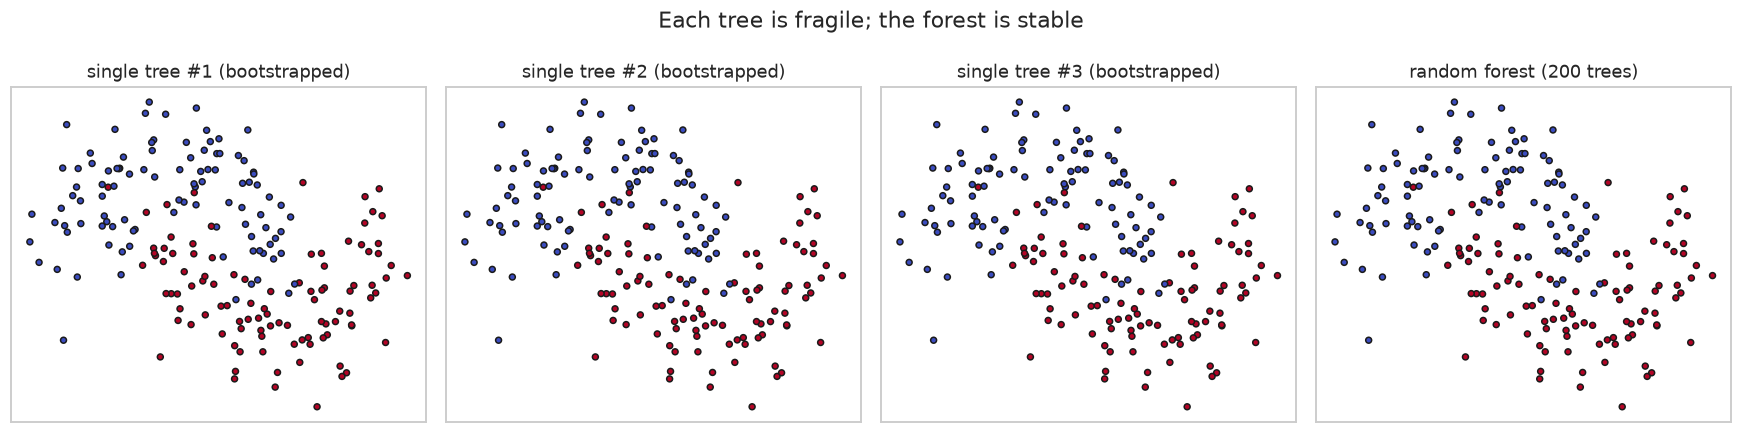

In [1]:
from setup import *
from sklearn.datasets import make_moons

# A noisy 2-moons dataset — classic high-variance territory for a single tree.
X, y = make_moons(n_samples=200, noise=0.25, random_state=0)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
# three individual trees + the forest
rng = np.random.RandomState(0)
for i, ax in enumerate(axes[:3]):
 idx = rng.choice(len(X), len(X), replace=True) # bootstrap sample
 t = DecisionTreeClassifier(random_state=i).fit(X[idx], y[idx])
 axes[i].scatter(X[:,0], X[:,1], c=y, cmap="coolwarm", edgecolor="k", s=15)
 axes[i].set_title(f"single tree #{i+1} (bootstrapped)")
# the forest (200 trees)
forest = RandomForestClassifier(n_estimators=200, random_state=0).fit(X, y)
axes[3].scatter(X[:,0], X[:,1], c=y, cmap="coolwarm", edgecolor="k", s=15)
axes[3].set_title("random forest (200 trees)")
for ax in axes:
 ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Each tree is fragile; the forest is stable")
plt.tight_layout(); plt.show()

Each bootstrapped tree carves a slightly different staircase. Individually
they're noisy, but when 200 of them vote, the boundary smooths into a stable,
sensible curve. That's the variance reduction in pictures.

## 3. Out‑of‑bag (OOB) error — a free validation score

Each bootstrap sample leaves out ~37% of rows on average — the **out‑of‑bag**
rows. For each tree, those left‑out rows are a ready‑made validation set. OOB
error averages each tree's error on its own OOB rows → **a validation score
without a separate split or CV**. Extremely handy for fast iteration.

In [2]:
from sklearn.datasets import load_breast_cancer
bc = load_breast_cancer(as_frame=True)
Xb, yb = bc.data, bc.target

# OOB vs explicit test set — they should be close.
X_tr, X_te, y_tr, y_te = train_test_split(Xb, yb, test_size=0.3, random_state=42, stratify=yb)
rf = RandomForestClassifier(n_estimators=300, oob_score=True, random_state=42).fit(X_tr, y_tr)
print(f"OOB AUC : {rf.oob_decision_function_[:,1].__len__()} rows scored; "
 f"OOB accuracy = {rf.oob_score_:.3f}")
print(f"Test accuracy: {rf.score(X_te, y_te):.3f}")
print(f"Test AUC : {roc_auc_score(y_te, rf.predict_proba(X_te)[:,1]):.3f}")

OOB AUC : 398 rows scored; OOB accuracy = 0.967
Test accuracy: 0.942
Test AUC : 0.992


**OOB accuracy tracks test accuracy closely** because both measure
generalisation to unseen rows. Use OOB during development (it's free), then
confirm with a held‑out test set / CV for the final number (notebook 05).

## 4. Tuning the three knobs that matter

| Hyperparameter | What it controls | Effect | Typical |
|---|---|---|---|
| `n_estimators` | number of trees | more = smoother, lower variance; plateaus | 100–1000 |
| `max_features` | features per split | smaller = more random = more de‑correlation | "sqrt" (clf), None or 0.33 (reg) |
| `max_depth` | tree depth | shallower = higher bias, lower variance | None (let it grow) or tuned |

**Rule of thumb:** `n_estimators` "the more the merrier" up to a plateau (watch
the OOB curve); `max_features` and `max_depth` are the real tuning dials.

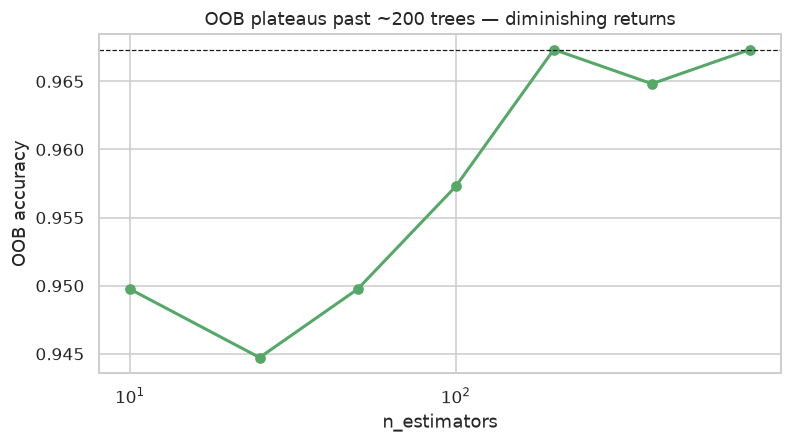

best OOB at n_estimators = 200


In [3]:
# OOB error vs n_estimators — find the plateau.
n_trees = [10, 25, 50, 100, 200, 400, 800]
oob = []
for n in n_trees:
 rf = RandomForestClassifier(n_estimators=n, oob_score=True, random_state=42,
 n_jobs=-1).fit(X_tr, y_tr)
 oob.append(rf.oob_score_)

plt.plot(n_trees, oob, "o-", color="#55a868", lw=2)
plt.xscale("log"); plt.xlabel("n_estimators"); plt.ylabel("OOB accuracy")
plt.title("OOB plateaus past ~200 trees — diminishing returns")
plt.axhline(max(oob), color="k", ls="--", lw=0.8)
plt.show()
print(f"best OOB at n_estimators = {n_trees[np.argmax(oob)]}")

In [4]:
# Proper grid search over max_features x max_depth via CV.
from sklearn.model_selection import GridSearchCV
param_grid = {
 "max_features": ["sqrt", 0.33, None],
 "max_depth": [4, 8, None],
}
gs = GridSearchCV(RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
 param_grid, cv=5, scoring="roc_auc", n_jobs=-1)
gs.fit(X_tr, y_tr)
cv_results = (pd.DataFrame(gs.cv_results_)
 .sort_values("rank_test_score")
 [["param_max_features", "param_max_depth", "mean_test_score", "std_test_score"]]
 .head(8))
cv_results.round(3)

,param_max_features,param_max_depth,mean_test_score,std_test_score
3,sqrt,8,0.988,0.011
6,sqrt,None,0.988,0.011
0,sqrt,4,0.986,0.013
5,None,8,0.986,0.014
8,None,None,0.986,0.014
2,None,4,0.985,0.014
7,0.33,None,0.984,0.014
4,0.33,8,0.984,0.014


**Reading the grid:** the differences between top configs are usually small
(forests are robust). Pick the simplest config within 1 std of the best — don't
chase the 4th decimal, it's noise (§5).

## 5. Permutation importance — the honest feature ranking

Recall from notebook 07 that tree `feature_importances_` is **biased toward
high‑cardinality features**. **Permutation importance** fixes this: shuffle one
feature's values, measure how much the score drops. A drop = the feature
mattered; no drop = it didn't, regardless of cardinality.

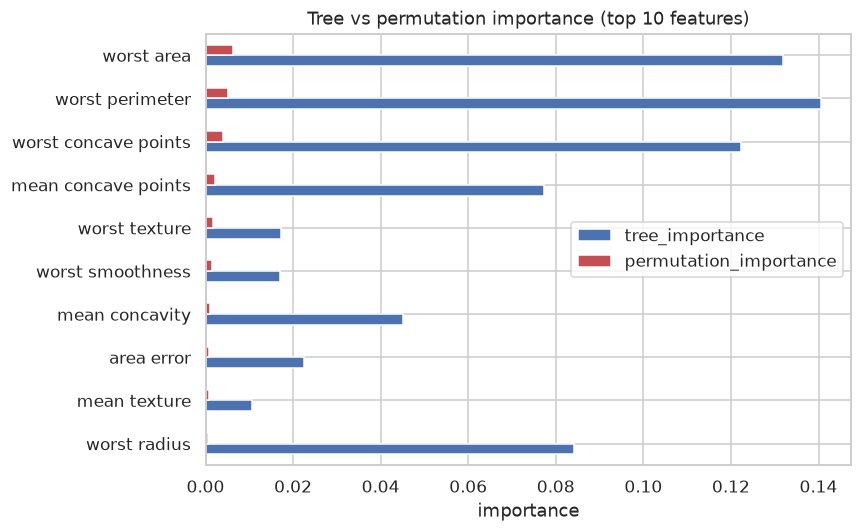

In [5]:
from sklearn.inspection import permutation_importance

rf_best = gs.best_estimator_.fit(X_tr, y_tr)
# Tree's built-in importance (biased toward high-cardinality)
tree_imp = pd.Series(rf_best.feature_importances_, index=Xb.columns)

# Permutation importance (computed on the test set — honest)
perm = permutation_importance(rf_best, X_te, y_te, n_repeats=10,
 random_state=42, scoring="roc_auc")
perm_imp = pd.Series(perm.importances_mean, index=Xb.columns)

cmp = pd.DataFrame({"tree_importance": tree_imp, "permutation_importance": perm_imp})
cmp = cmp.sort_values("permutation_importance", ascending=True).tail(10)
cmp.plot(kind="barh", figsize=(8, 5), color=["#4c72b0", "#c44e52"])
plt.xlabel("importance"); plt.title("Tree vs permutation importance (top 10 features)")
plt.tight_layout(); plt.show()

**What to look for:** the two rankings usually agree on the *top* features but
diverge in the middle. Where they diverge, trust **permutation** — it's
cardinality‑unbiased and measures actual impact on held‑out performance.

> Permutation importance has its own caveat: if two features are highly
> correlated (§7.2), shuffling one barely hurts because the other carries
> the same information. The fix: drop correlated features first, or use SHAP
> values for the definitive view.

## 6. Random forest vs gradient boosting

Both are tree ensembles, but they combine trees **oppositely**:

| | Random Forest | Gradient Boosting |
|---|---|---|
| **How trees combine** | average many **independent** deep trees | add many **sequential** shallow trees, each fixing the last's errors |
| **Bias/variance** | reduces **variance** (§6.1) | reduces **bias** |
| **Overfit dial** | `n_estimators` ↑ = safer | `n_estimators` ↑ = riskier (must add learning rate, early stopping) |
| **Typical accuracy** | strong, robust, few knobs | usually higher, but more tuning |
| **Tuning effort** | low | medium‑high |

Let's compare on the breast‑cancer dataset.

In [6]:
import lightgbm as lgb
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

models = {
 "logreg": LogisticRegression(max_iter=5000),
 "random_forest": RandomForestClassifier(n_estimators=300, max_features="sqrt",
 random_state=42, n_jobs=-1),
 "xgboost": XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=3,
 subsample=0.8, colsample_bytree=0.8,
 eval_metric="logloss", random_state=42, n_jobs=-1),
 "lightgbm": lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05,
 num_leaves=15, subsample=0.8,
 colsample_bytree=0.8, random_state=42, n_jobs=-1,
 verbose=-1),
}
rows = []
for name, m in models.items():
 s = cross_val_score(m, Xb, yb, cv=5, scoring="roc_auc")
 rows.append({"model": name, "cv_auc": s.mean(), "std": s.std()})
pd.DataFrame(rows).sort_values("cv_auc", ascending=False).round(3)

,model,cv_auc,std
3,lightgbm,0.994,0.004
2,xgboost,0.993,0.005
0,logreg,0.992,0.007
1,random_forest,0.992,0.006


**Typical outcome:** boosting (xgboost/lightgbm) usually edges out the forest,
which edges out logistic regression — on this clean, tabular dataset. **But
always verify on *your* data**; the ordering flips on sparse / very high‑
dimensional / mostly‑linear problems. Report mean ± std (§5) — the gaps here
may be within noise.

## 7. Failure case — the forest that hides a leak

A forest is robust and accurate, which **lulls you into trusting it**. But it
has no special immunity to data leakage (notebook 02/03): a leaky feature sails
straight through, importance‑ranked at the top, looking like a hero. This is
the most dangerous failure mode because nothing *looks* wrong.

In [7]:
# Inject a leaky feature: a noisy copy of the target. It carries no REAL signal
# a human would have at prediction time — it's a stand-in for "a column computed
# from the target" or "a future‑leaking timestamp".
rng = np.random.default_rng(0)
X_leak = Xb.copy()
X_leak["leaky"] = yb.values + rng.normal(0, 0.15, len(yb))

rf_leak = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
s = cross_val_score(rf_leak, X_leak, yb, cv=5, scoring="roc_auc")
print(f"CV AUC WITH leaky feature: {s.mean():.3f} ± {s.std():.3f}")
s_clean = cross_val_score(RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
 Xb, yb, cv=5, scoring="roc_auc")
print(f"CV AUC clean : {s_clean.mean():.3f} ± {s_clean.std():.3f}")

CV AUC WITH leaky feature: 1.000 ± 0.000
CV AUC clean : 0.992 ± 0.006


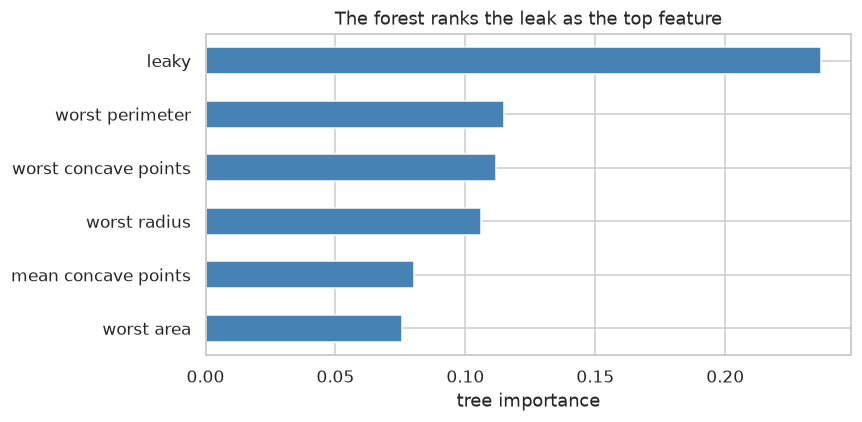

In [8]:
# And the forest happily ranks the leak as the #1 feature.
rf_leak.fit(X_leak, yb)
imp = pd.Series(rf_leak.feature_importances_, index=X_leak.columns).sort_values()
imp.tail(6).plot(kind="barh", color="steelblue")
plt.xlabel("tree importance"); plt.title("The forest ranks the leak as the top feature")
plt.tight_layout(); plt.show()

**The trap, in one sentence:** a near‑perfect CV AUC on a real‑world (messy)
problem is **evidence of leakage, not of a great model**. Forests don't rescue
you from the leakage checklist (notebook 02/03) — they make the leak *easier to
miss* because everything else looks fine.

> The discipline from notebooks 02/03 still applies, *especially* with powerful
> models. Suspiciously high score → assume leakage. Audit the top features:
> "could I know this value at prediction time?" If no, drop it.

## Common pitfalls & how to avoid shooting yourself in the foot

1. **Leaky features look like heroes (§7).** A forest won't flag them — you must.
 Run the leakage checklist on the top‑importance features every time.
2. **Using biased `feature_importances_` (§5).** Switch to permutation
 importance (or SHAP) for any real interpretation. Tree importance lies about
 high‑cardinality / correlated features (notebook 07 §4).
3. **Tuning `n_estimators` too hard.** Past the plateau (~200–500), more trees
 barely help and just cost time/memory. Spend the effort on `max_features`
 and `max_depth`.
4. **Treating OOB as the final score.** OOB is great for iteration; the final
 reported number should come from a held‑out test set / CV (notebook 05).
5. **Forgetting `random_state` + `n_jobs`.** Without a seed your importances
 wobble run‑to‑run; without `n_jobs=-1` a 1000‑tree forest is needlessly slow.
6. **Reaching for boosting by default.** Forests need far less tuning and are
 more robust to noisy features / small data. Try a forest first; reach for
 xgboost/lightgbm only if you have time to tune and need the extra accuracy.
7. **Interpreting forest predictions as causal (§3).** "The forest weighted
 income heavily → income drives churn" is the same trap as for single trees.

## Exercises

1. **OOB vs CV.** On the breast‑cancer data, compare OOB accuracy to 5‑fold CV
 accuracy for a 300‑tree forest. Are they within 1% of each other? Why?
2. **`max_features` effect.** Fit three forests with `max_features` = 1, "sqrt",
 and None (all). Compare OOB accuracy and the *spread* of the trees' structures.
 How does de‑correlation show up?
3. **Permutation vs tree importance.** Add a column of random unique integers to
 breast‑cancer features. Which importance method flags it as useless, and
 which wrongly elevates it? Why?
4. **Boosting tuning.** On breast‑cancer, xgboost with `n_estimators=2000` and
 `learning_rate=0.1` (no early stopping) — does it overfit? Refit with
 `learning_rate=0.01` and `n_estimators=2000`. What changes?
5. **Leak audit.** Build a "MonthlyRevenue" feature for Telco churn that equals
 `TotalCharges / tenure` — sounds legit, but if churn is defined via revenue
 dropping, is it leaky? How would you test it?

<details><summary>Answers (click to expand)</summary>

```python
# 1
rf = RandomForestClassifier(n_estimators=300, oob_score=True, random_state=42).fit(Xb, yb)
print(rf.oob_score_, cross_val_score(RandomForestClassifier(n_estimators=300, random_state=42), Xb, yb, cv=5).mean())
# OOB and CV measure the same thing (generalisation to held-out rows); they
# agree to within sampling noise.

# 2: max_features=1 -> trees are very different (maximally de-correlated) but
# high-bias; None -> trees are identical to bagged full trees (correlated);
# sqrt -> the sweet spot. OOB accuracy is usually best at sqrt.

# 3: Tree importance gives the random-id column HIGH importance (cardinality
# bias — many split points). Permutation importance correctly gives it ~0.
# This is the cardinality-bias warning from notebook 07.

# 4: n_estimators=2000, lr=0.1, no early stopping -> CV AUC usually drops vs
# 300 trees (overfit). lr=0.01, 2000 trees -> closer to or better than 300
# (slow learning, less overfit per step). Always use early stopping in
# practice (early_stopping_rounds).

# 5: If churn = "revenue dropped > X%", then MonthlyRevenue (derived from
# revenue) partly encodes the label -> leaky. Test: drop tenure; if CV AUC
# collapses, the feature was carrying label info via the target definition.
```
</details>

## References

- **Theory & Statistics Reference** (`00_Theory_Reference.ipynb`) — §6.1
 (variance reduction by averaging), §6.2 (the bias/variance dials behind each
 hyperparameter), §7.2 (correlated features & importance), §3 (correlation
 vs causation for interpretation).
- Textbook: Boehmke & Greenwell, *HOML*, Ch. 11 —
 <https://bradleyboehmke.github.io/HOML/random-forests.html>.
- Breiman (2001), *Random Forests*, Machine Learning — the original paper.
- scikit‑learn — *Permutation feature importance*:
 <https://scikit-learn.org/stable/modules/permutation_importance.html>.
- Chen & Guestrin (2016), *XGBoost*; Ke et al. (2017), *LightGBM*.